# Diagramme pôles-zéros

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from scipy.signal import tf2zpk

plt.style.use('../../src/signal.mplstyle')

In [2]:
def pzplot(fname, b, a, title="", num=False):
    
     # Préparation de la figure
    fig, ax = plt.subplots(1, 1, figsize=(4,4))
    ax.set_aspect('equal')
    ax.set_axisbelow(True)

    # Pôles et zéros
    z, p, k = tf2zpk(b, a)
    print(f"Pôles : {p}")
    print(f"Zéros : {z}")
    ax.plot(np.real(z), np.imag(z), marker='o', linestyle="None", markersize=8, markerfacecolor="None", color='tab:blue', markeredgewidth=1.5)
    ax.plot(np.real(p), np.imag(p), marker='x', linestyle="None", markersize=8, color='tab:blue', markeredgewidth=1.5)

    # Axes
    pts = np.concatenate( (np.real(z), np.imag(z), np.real(p), np.imag(p)) )
    N = np.max(abs(pts)) + 1
    ax.set_xlim([-N, N])
    ax.set_ylim([-N, N])

    # Analogique ou numérique ?
    if num:
        t = np.linspace(0, 2*np.pi, 30)
        ax.plot(np.cos(t), np.sin(t), color='k', linewidth=1)
    else:
        ax.plot([0, 0], [-10, 10], color='k', linewidth=1)
    
    # Labels
    ax.set_xlabel('$\\sigma$')
    ax.set_ylabel('$\\omega$')
    ax.set_title(title)

    # Enregistrement et affichage
    plt.savefig(fname)
    plt.savefig(fname[:-3]+"png")
    plt.show()

Pôles : [-3.+4.j -3.-4.j]
Zéros : []


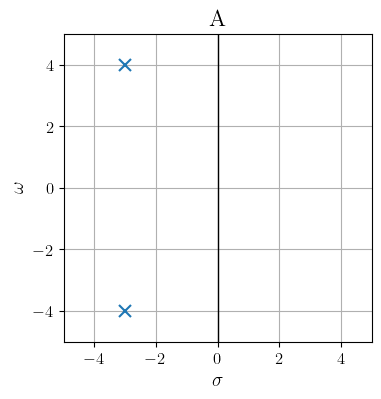

Pôles : [-0.+0.5j  0.-0.5j]
Zéros : [-2.]


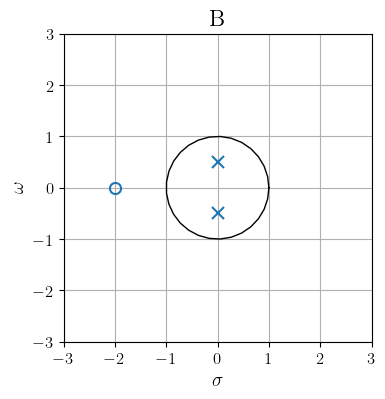

Pôles : [ 0.81356475+1.0540462j   0.81356475-1.0540462j  -1.11488364+0.j
 -0.25612293+0.48780727j -0.25612293-0.48780727j]
Zéros : [-5.93549689+0.j          0.18453489+0.86203683j  0.18453489-0.86203683j
 -0.4335729 +0.j        ]


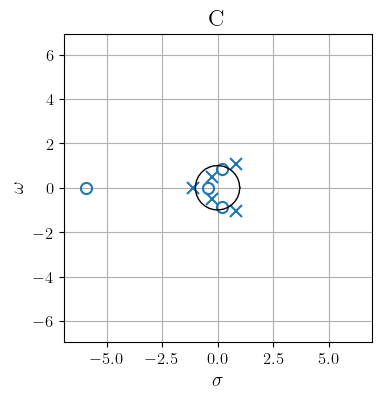

In [3]:
pzplot("pz1.svg", b = [25], a = [1, 6, 25], title="A", num=False)
pzplot("pz2.svg", b = [1, 2], a = [1, 0, 1/4], title="B", num=True)
pzplot("pz3.svg", b = [1, 6, 1, 4, 2], a = [5, 0, 0, 9, 5, 3], title="C", num=True)